# Analisis de los metodos de clasificacion

En este ejemplo que vamos hacer, vamos a crear un analisis sobre los datos de 
vino, y vamos a evaluar cual es la mejor tecnica de clasificacion, en este caso vamos 
a usar dos clasification tree and random forest y con una tecnica de analisis lograremos decir
cual de los modelos es el mejor de todos

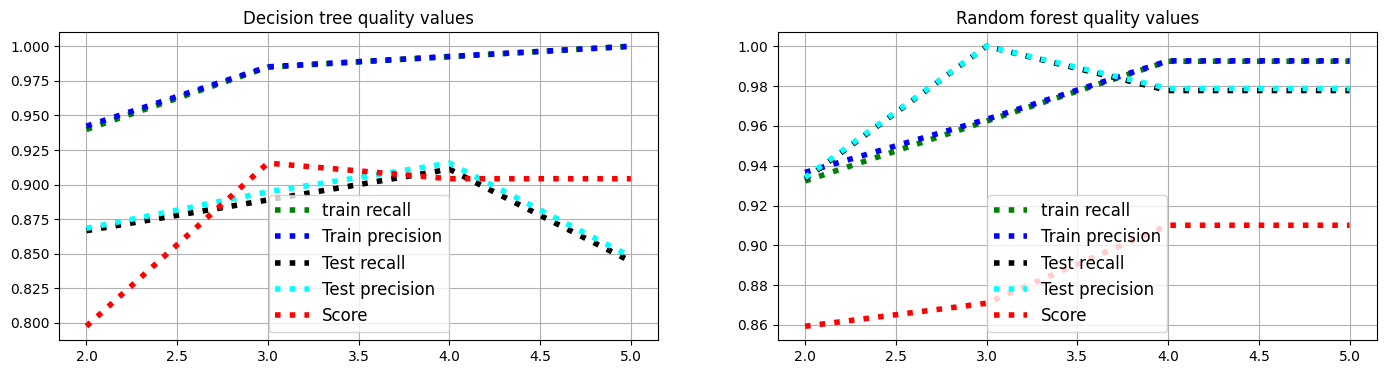

In [22]:
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import precision_score,recall_score
import numpy as np
import matplotlib.pyplot as plt


wine = load_wine()

X = wine.data
y = wine.target

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=60)

tree_score = [[],[]]
tree_precision_train = [[],[]]; tree_recall_train = [[],[]]
tree_precision_test = [[],[]]; tree_recall_test = [[],[]]

tree = [0,0]
depth = range(2,6)
DECISION_TREE =  0; RANDOM_FOREST = 1

for max_depth in depth:
    for i in [DECISION_TREE,RANDOM_FOREST]:
        if (i == DECISION_TREE):
            tree[DECISION_TREE] = DecisionTreeClassifier(max_depth=max_depth,
                                                         random_state=10)
        else:
            tree[RANDOM_FOREST] = RandomForestClassifier(n_estimators=3,
                                                         max_depth=max_depth,random_state=10)
        tree[i].fit(X_train,y_train)
        tree_score[i].append(np.mean(cross_val_score(tree[i],X,y,cv=3)))

        y_pred_train = tree[i].predict(X_train)
        y_pred_test = tree[i].predict(X_test)

        tree_precision_train[i].append(precision_score(y_train,
                                                       y_pred_train,average='weighted'))
        
        tree_recall_train[i].append(recall_score(y_train,y_pred_train,
                                                 average='weighted'))
        

        tree_precision_test[i].append(precision_score(y_test,y_pred_test,
                                                      average='weighted'))
        
        tree_recall_test[i].append(recall_score(y_test,y_pred_test,
                                                average='weighted'))
        

fig,axs = plt.subplots(1,2,figsize=(17,4))

for i in [DECISION_TREE,RANDOM_FOREST]:
    axs[i].plot(depth,tree_recall_train[i],color='green',linestyle=':',
                linewidth=4.0,label='train recall')
    
    axs[i].plot(depth,tree_precision_train[i], color='blue', linestyle=':',
                linewidth=4.0,label='Train precision')
    
    axs[i].plot(depth,tree_recall_test[i], color='black', linestyle=':',
                linewidth=4.0,label='Test recall')
    
    axs[i].plot(depth,tree_precision_test[i], color='cyan', linestyle=':',
                linewidth=4.0,label='Test precision')
    
    axs[i].plot(depth,tree_score[i], color='red', linestyle=':',
                linewidth=4.0,label='Score')
    

    if (i == DECISION_TREE):
        axs[i].set_title('Decision tree quality values')
    else:
        axs[i].set_title('Random forest quality values')
    
    axs[i].grid()
    axs[i].legend(fontsize='large')

plt.show()
